In [10]:
import pandas as pd
import numpy as np
from pycaret.classification import load_model, predict_model
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import joblib

# Innit


In [11]:
# Innit
data_24_25 = pd.read_csv('../../data/joint/24-25/merged_player_data.csv')

data_36 = data_24_25[data_24_25['event'] == 36]
data_37 = data_24_25[data_24_25['event'] == 37]
data_38 = data_24_25[data_24_25['event'] == 38]

data_36_gk = data_36[data_36['position'] == 'GK']
data_37_gk = data_37[data_37['position'] == 'GK']
data_38_gk = data_38[data_38['position'] == 'GK']

data_36_def = data_36[data_36['position'] == 'DEF']
data_37_def = data_37[data_37['position'] == 'DEF']
data_38_def = data_38[data_38['position'] == 'DEF']

data_36_mid = data_36[data_36['position'] == 'MID']
data_37_mid = data_37[data_37['position'] == 'MID']
data_38_mid = data_38[data_38['position'] == 'MID']

data_36_fwd = data_36[data_36['position'] == 'FWD']
data_37_fwd = data_37[data_37['position'] == 'FWD']
data_38_fwd = data_38[data_38['position'] == 'FWD']


# Clean Sheets


In [ ]:
cs_features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty',  'ownership_change', 'percenatge_net_transfers',
            'clean_sheets',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1',  'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_5',  'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]


## GK


In [13]:
# Load model
g_cs_model = load_model('../gk_cs_model')

Transformation Pipeline and Model Successfully Loaded


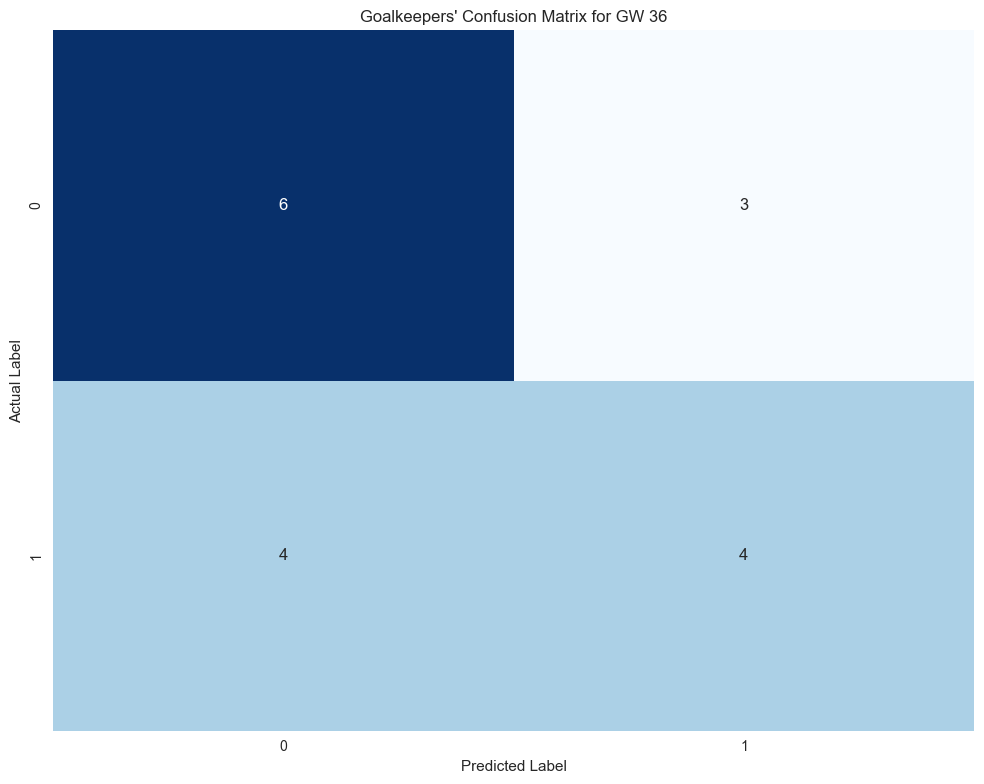

In [14]:
data_36_gk_cs = data_36_gk[cs_features]
cs = data_36_gk_cs[['clean_sheets']].copy()
data_36_gk_cs.drop(columns=['position', 'clean_sheets'], inplace=True)

cs_preds_36 = predict_model(g_cs_model, data=data_36_gk_cs)
cs_preds_36 = cs_preds_36.rename(columns={'prediction_label': 'cs_preds_trans'})

# Add cs_preds_36 to data_36_gk
data_36_gk['cs_preds'] = cs_preds_36[['cs_preds_trans']]


actual = cs['clean_sheets'] # The actual classes
predicted = cs_preds_36[['cs_preds_trans']] # The predicted classes

cm = confusion_matrix(actual, predicted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Label the axes
plt.title('Goalkeepers\' Confusion Matrix for GW 36')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()



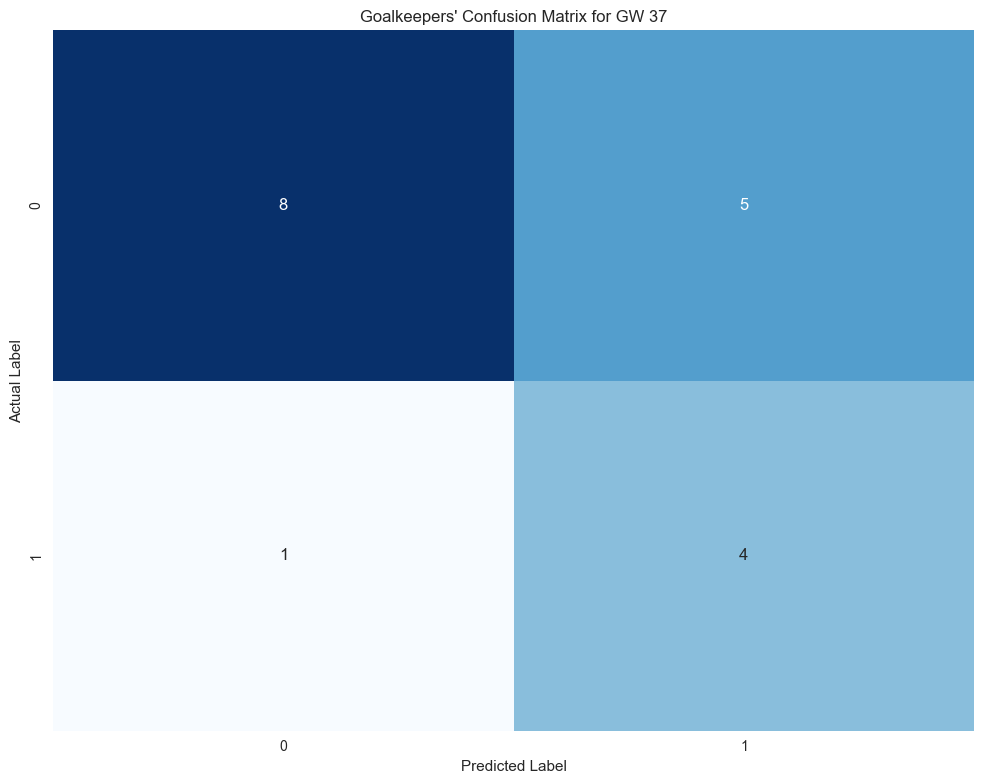

In [15]:
data_37_gk_cs = data_37_gk[cs_features]
cs = data_37_gk_cs[['clean_sheets']].copy()
data_37_gk_cs.drop(columns=['position', 'clean_sheets'], inplace=True)

cs_preds_37 = predict_model(g_cs_model, data=data_37_gk_cs)
cs_preds_37 = cs_preds_37.rename(columns={'prediction_label': 'cs_preds_trans'})

# Add cs_preds_37 to data_37_gk
data_37_gk['cs_preds'] = cs_preds_37[['cs_preds_trans']]


actual = cs['clean_sheets'] # The actual classes
predicted = cs_preds_37[['cs_preds_trans']] # The predicted classes

cm = confusion_matrix(actual, predicted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Label the axes
plt.title('Goalkeepers\' Confusion Matrix for GW 37')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()



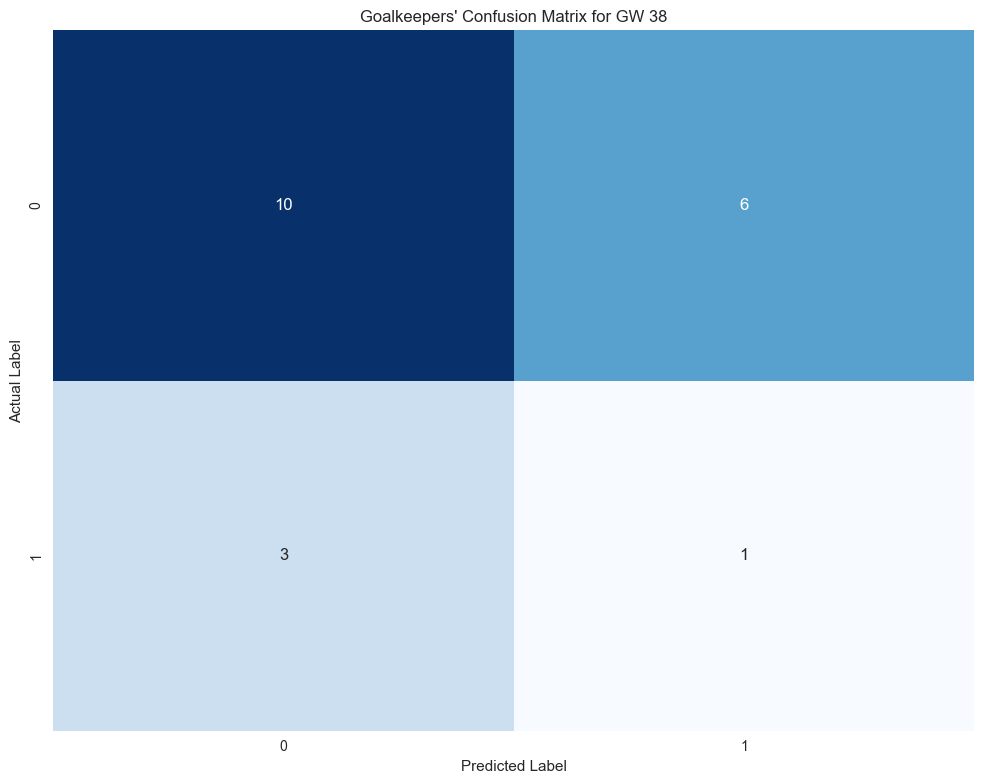

In [16]:
data_38_gk_cs = data_38_gk[cs_features]
cs = data_38_gk_cs[['clean_sheets']].copy()
data_38_gk_cs.drop(columns=['position', 'clean_sheets'], inplace=True)

cs_preds_38 = predict_model(g_cs_model, data=data_38_gk_cs)
cs_preds_38 = cs_preds_38.rename(columns={'prediction_label': 'cs_preds_trans'})

# Add cs_preds_38 to data_38_gk
data_38_gk['cs_preds'] = cs_preds_38[['cs_preds_trans']]


actual = cs['clean_sheets'] # The actual classes
predicted = cs_preds_38[['cs_preds_trans']] # The predicted classes

cm = confusion_matrix(actual, predicted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Label the axes
plt.title('Goalkeepers\' Confusion Matrix for GW 38')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()



## DEF


In [17]:
# Load model
def_cs_model = load_model('../def_cs_model')

Transformation Pipeline and Model Successfully Loaded


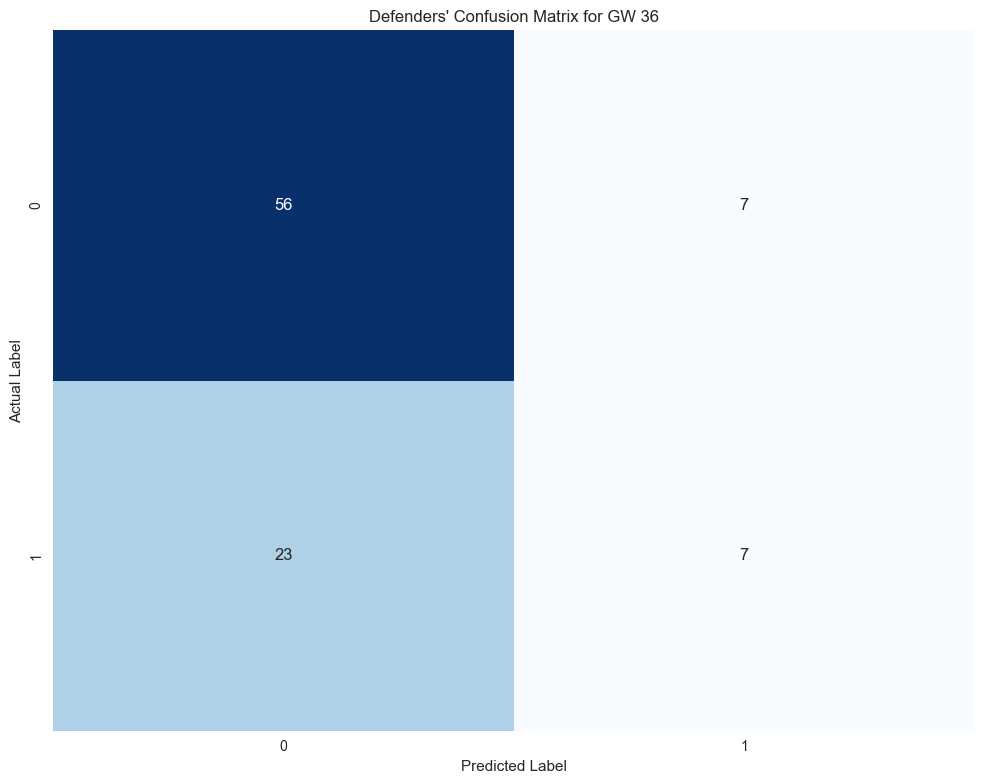

In [18]:
data_36_def_cs = data_36_def[cs_features]
cs = data_36_def_cs[['clean_sheets']].copy()
data_36_def_cs.drop(columns=['position', 'clean_sheets'], inplace=True)

cs_preds_36 = predict_model(def_cs_model, data=data_36_def_cs)
cs_preds_36 = cs_preds_36.rename(columns={'prediction_label': 'cs_preds_trans'})

# Add cs_preds_36 to data_36_def
data_36_def['cs_preds'] = cs_preds_36[['cs_preds_trans']]


actual = cs['clean_sheets'] # The actual classes
predicted = cs_preds_36[['cs_preds_trans']] # The predicted classes

cm = confusion_matrix(actual, predicted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Label the axes
plt.title('Defenders\' Confusion Matrix for GW 36')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()



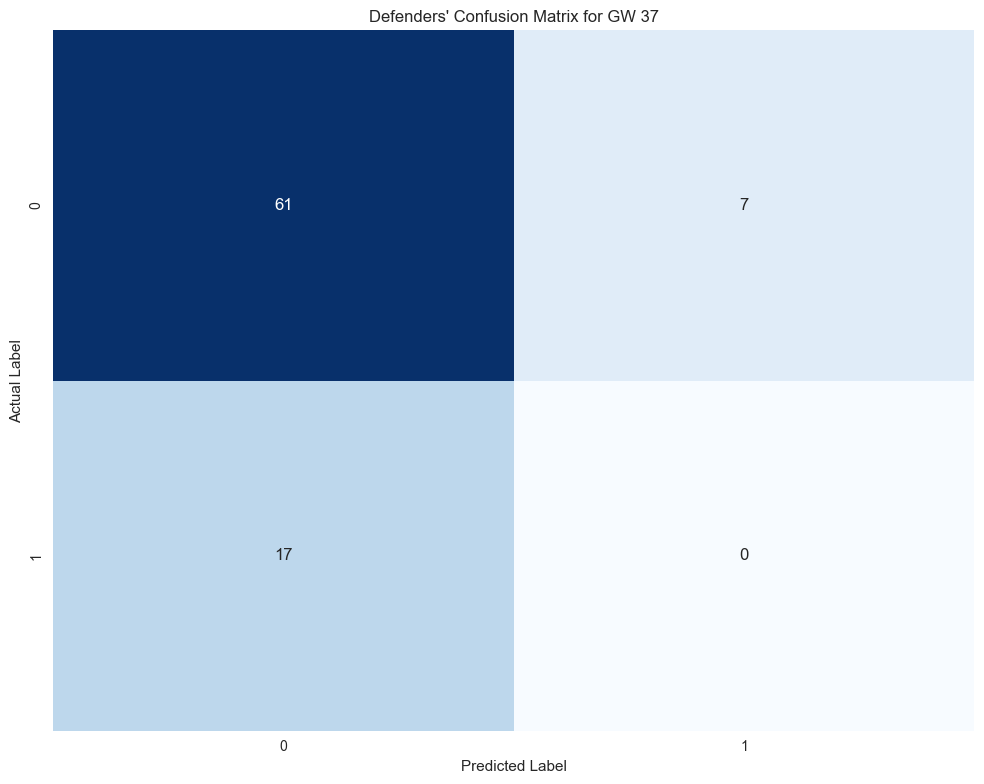

In [19]:
data_37_def_cs = data_37_def[cs_features]
cs = data_37_def_cs[['clean_sheets']].copy()
data_37_def_cs.drop(columns=['position', 'clean_sheets'], inplace=True)

cs_preds_37 = predict_model(def_cs_model, data=data_37_def_cs)
cs_preds_37 = cs_preds_37.rename(columns={'prediction_label': 'cs_preds_trans'})

# Add cs_preds_37 to data_37_def
data_37_def['cs_preds'] = cs_preds_37[['cs_preds_trans']]


actual = cs['clean_sheets'] # The actual classes
predicted = cs_preds_37[['cs_preds_trans']] # The predicted classes

cm = confusion_matrix(actual, predicted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Label the axes
plt.title('Defenders\' Confusion Matrix for GW 37')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()



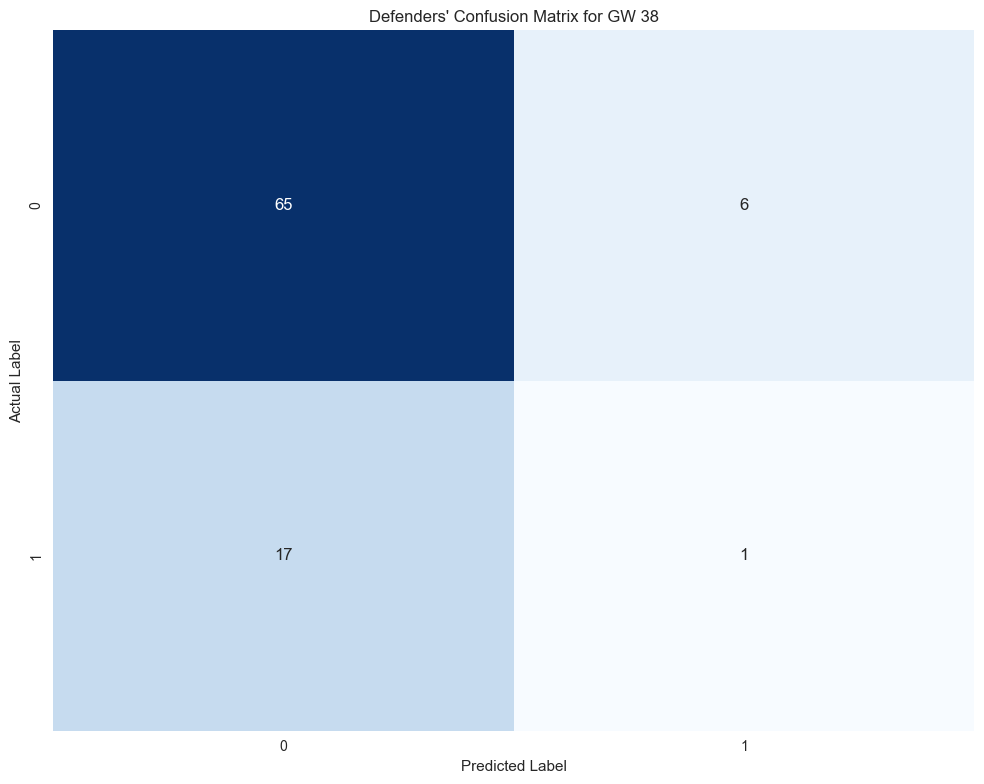

In [20]:
data_38_def_cs = data_38_def[cs_features]
cs = data_38_def_cs[['clean_sheets']].copy()
data_38_def_cs.drop(columns=['position', 'clean_sheets'], inplace=True)

cs_preds_38 = predict_model(def_cs_model, data=data_38_def_cs)
cs_preds_38 = cs_preds_38.rename(columns={'prediction_label': 'cs_preds_trans'})

# Add cs_preds_38 to data_38_def
data_38_def['cs_preds'] = cs_preds_38[['cs_preds_trans']]


actual = cs['clean_sheets'] # The actual classes
predicted = cs_preds_38[['cs_preds_trans']] # The predicted classes

cm = confusion_matrix(actual, predicted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Label the axes
plt.title('Defenders\' Confusion Matrix for GW 38')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()



## MID


In [21]:
# Load model
mid_cs_model = load_model('../mid_cs_model')

Transformation Pipeline and Model Successfully Loaded


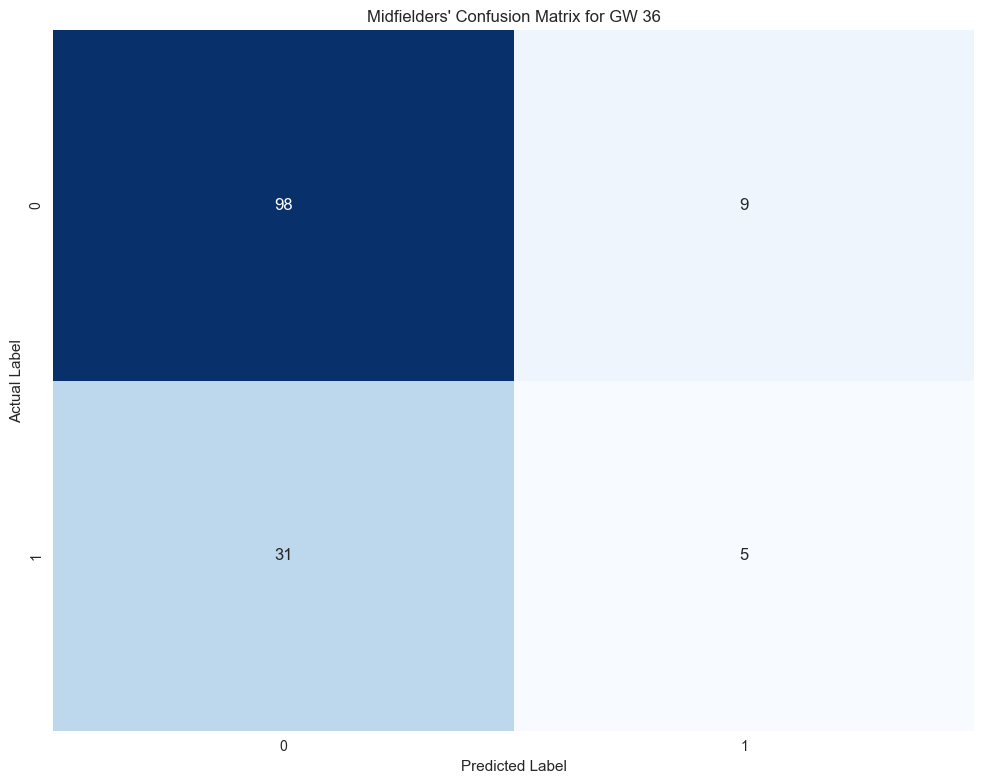

In [22]:
data_36_mid_cs = data_36_mid[cs_features]
cs = data_36_mid_cs[['clean_sheets']].copy()
data_36_mid_cs.drop(columns=['position', 'clean_sheets'], inplace=True)

cs_preds_36 = predict_model(mid_cs_model, data=data_36_mid_cs)
cs_preds_36 = cs_preds_36.rename(columns={'prediction_label': 'cs_preds_trans'})

# Add cs_preds_36 to data_36_mid
data_36_mid['cs_preds'] = cs_preds_36[['cs_preds_trans']]


actual = cs['clean_sheets'] # The actual classes
predicted = cs_preds_36[['cs_preds_trans']] # The predicted classes

cm = confusion_matrix(actual, predicted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Label the axes
plt.title('Midfielders\' Confusion Matrix for GW 36')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()



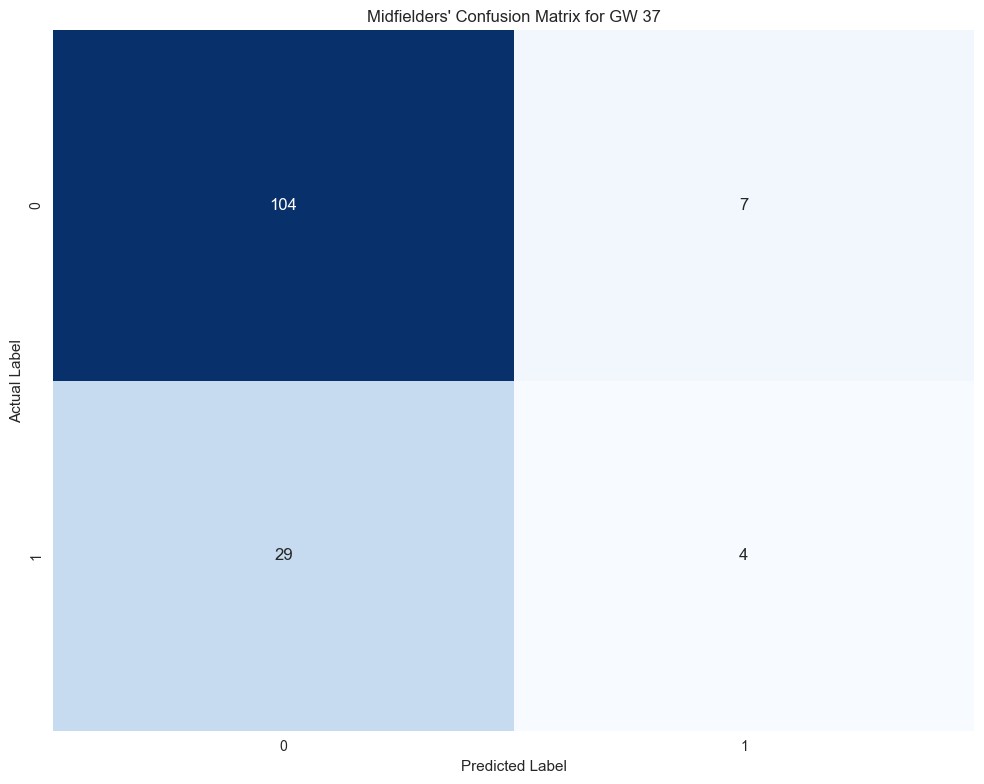

In [23]:
data_37_mid_cs = data_37_mid[cs_features]
cs = data_37_mid_cs[['clean_sheets']].copy()
data_37_mid_cs.drop(columns=['position', 'clean_sheets'], inplace=True)

cs_preds_37 = predict_model(mid_cs_model, data=data_37_mid_cs)
cs_preds_37 = cs_preds_37.rename(columns={'prediction_label': 'cs_preds_trans'})

# Add cs_preds_37 to data_37_mid
data_37_mid['cs_preds'] = cs_preds_37[['cs_preds_trans']]


actual = cs['clean_sheets'] # The actual classes
predicted = cs_preds_37[['cs_preds_trans']] # The predicted classes

cm = confusion_matrix(actual, predicted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Label the axes
plt.title('Midfielders\' Confusion Matrix for GW 37')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()



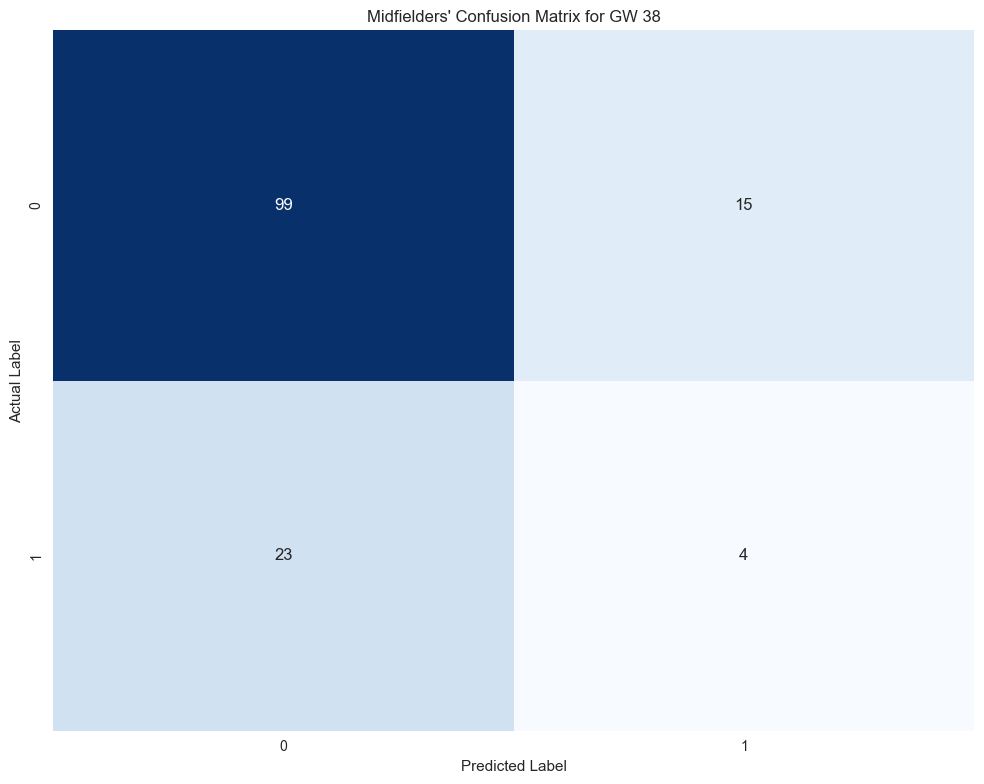

In [24]:
data_38_mid_cs = data_38_mid[cs_features]
cs = data_38_mid_cs[['clean_sheets']].copy()
data_38_mid_cs.drop(columns=['position', 'clean_sheets'], inplace=True)

cs_preds_38 = predict_model(mid_cs_model, data=data_38_mid_cs)
cs_preds_38 = cs_preds_38.rename(columns={'prediction_label': 'cs_preds_trans'})

# Add cs_preds_38 to data_38_mid
data_38_mid['cs_preds'] = cs_preds_38[['cs_preds_trans']]


actual = cs['clean_sheets'] # The actual classes
predicted = cs_preds_38[['cs_preds_trans']] # The predicted classes

cm = confusion_matrix(actual, predicted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Label the axes
plt.title('Midfielders\' Confusion Matrix for GW 38')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()



# Yellow Cards


In [ ]:
y_features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers',

                'yellow_cards',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1',  'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]


## GK


In [26]:
# Load model
g_y_model = load_model('../gk_y_model')

Transformation Pipeline and Model Successfully Loaded


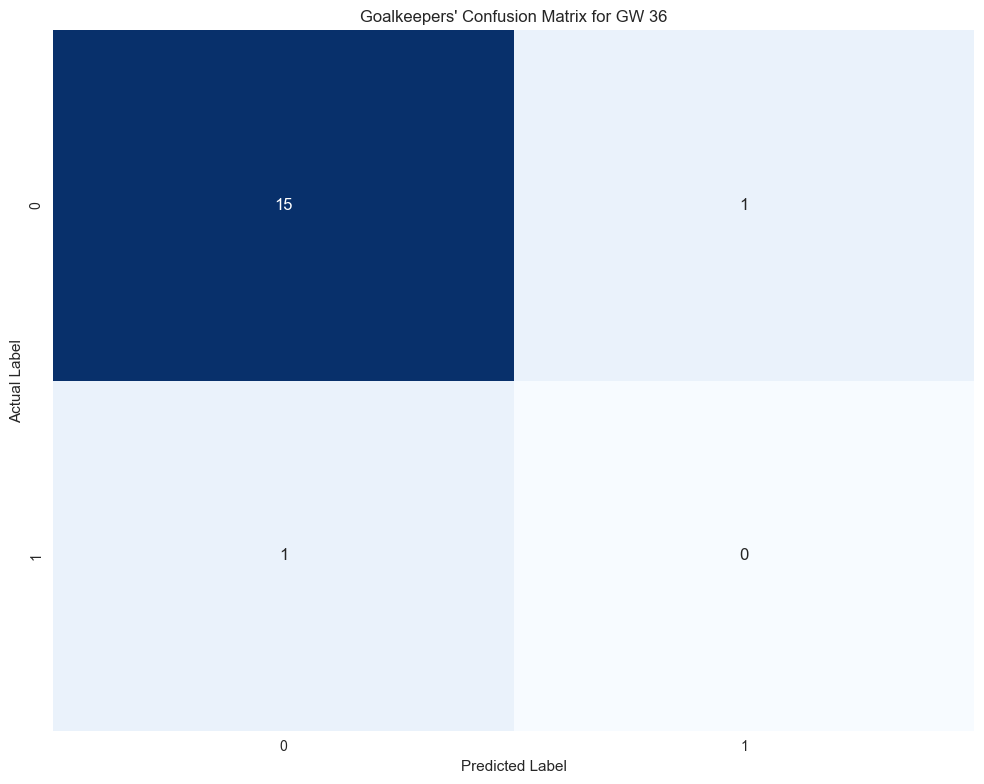

In [27]:
data_36_gk_y = data_36_gk[y_features]
y = data_36_gk_y[['yellow_cards']].copy()
data_36_gk_y.drop(columns=['position', 'yellow_cards'], inplace=True)

y_preds_36 = predict_model(g_y_model, data=data_36_gk_y)
y_preds_36 = y_preds_36.rename(columns={'prediction_label': 'y_preds_trans'})

# Add y_preds_36 to data_36_gk
data_36_gk['y_preds'] = y_preds_36[['y_preds_trans']]


actual = y['yellow_cards'] # The actual classes
predicted = y_preds_36[['y_preds_trans']] # The predicted classes

cm = confusion_matrix(actual, predicted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Label the axes
plt.title('Goalkeepers\' Confusion Matrix for GW 36')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()



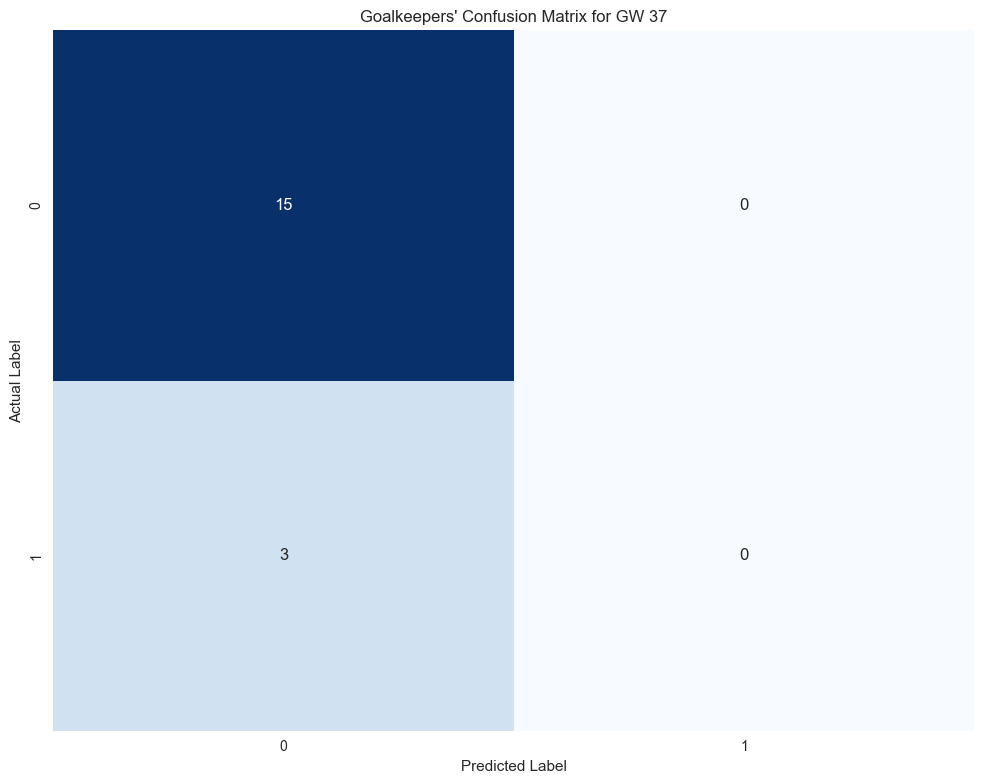

In [28]:
data_37_gk_y = data_37_gk[y_features]
y = data_37_gk_y[['yellow_cards']].copy()
data_37_gk_y.drop(columns=['position', 'yellow_cards'], inplace=True)

y_preds_37 = predict_model(g_y_model, data=data_37_gk_y)
y_preds_37 = y_preds_37.rename(columns={'prediction_label': 'y_preds_trans'})

# Add y_preds_37 to data_37_gk
data_37_gk['y_preds'] = y_preds_37[['y_preds_trans']]


actual = y['yellow_cards'] # The actual classes
predicted = y_preds_37[['y_preds_trans']] # The predicted classes

cm = confusion_matrix(actual, predicted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Label the axes
plt.title('Goalkeepers\' Confusion Matrix for GW 37')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()



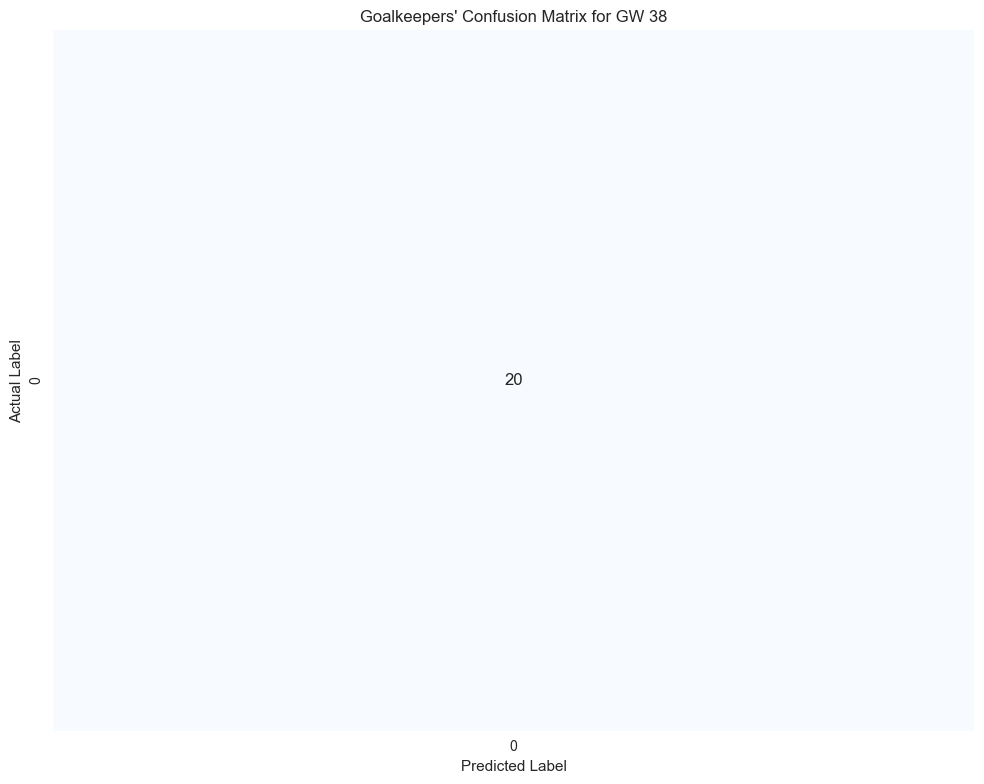

In [29]:
data_38_gk_y = data_38_gk[y_features]
y = data_38_gk_y[['yellow_cards']].copy()
data_38_gk_y.drop(columns=['position', 'yellow_cards'], inplace=True)

y_preds_38 = predict_model(g_y_model, data=data_38_gk_y)
y_preds_38 = y_preds_38.rename(columns={'prediction_label': 'y_preds_trans'})

# Add y_preds_38 to data_38_gk
data_38_gk['y_preds'] = y_preds_38[['y_preds_trans']]


actual = y['yellow_cards'] # The actual classes
predicted = y_preds_38[['y_preds_trans']] # The predicted classes

cm = confusion_matrix(actual, predicted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Label the axes
plt.title('Goalkeepers\' Confusion Matrix for GW 38')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()



## DEF


In [30]:
# Load model
def_y_model = load_model('../def_y_model')

Transformation Pipeline and Model Successfully Loaded


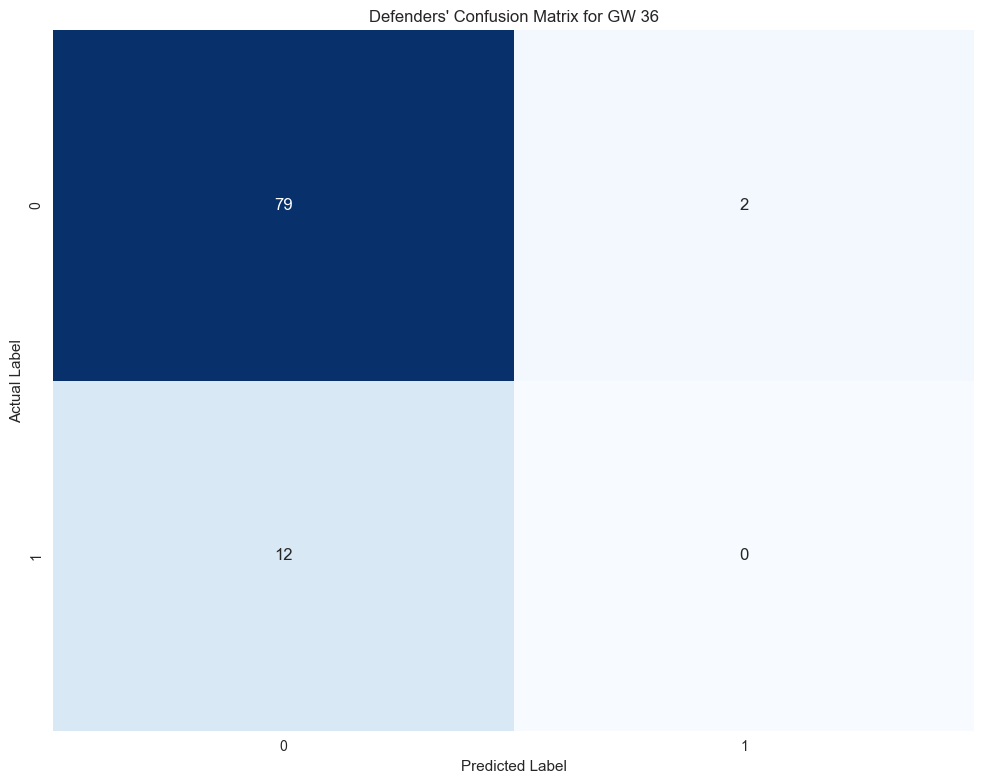

In [31]:
data_36_def_y = data_36_def[y_features]
y = data_36_def_y[['yellow_cards']].copy()
data_36_def_y.drop(columns=['position', 'yellow_cards'], inplace=True)

y_preds_36 = predict_model(def_y_model, data=data_36_def_y)
y_preds_36 = y_preds_36.rename(columns={'prediction_label': 'y_preds_trans'})

# Add y_preds_36 to data_36_def
data_36_def['y_preds'] = y_preds_36[['y_preds_trans']]


actual = y['yellow_cards'] # The actual classes
predicted = y_preds_36[['y_preds_trans']] # The predicted classes

cm = confusion_matrix(actual, predicted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Label the axes
plt.title('Defenders\' Confusion Matrix for GW 36')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()



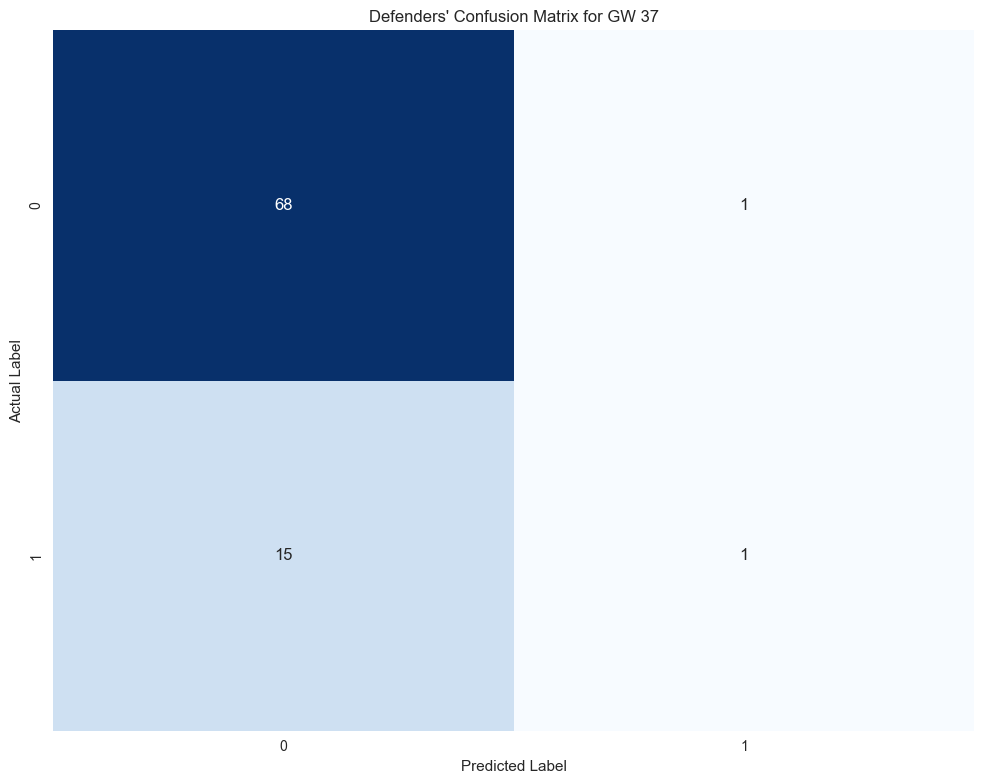

In [32]:
data_37_def_y = data_37_def[y_features]
y = data_37_def_y[['yellow_cards']].copy()
data_37_def_y.drop(columns=['position', 'yellow_cards'], inplace=True)

y_preds_37 = predict_model(def_y_model, data=data_37_def_y)
y_preds_37 = y_preds_37.rename(columns={'prediction_label': 'y_preds_trans'})

# Add y_preds_37 to data_37_def
data_37_def['y_preds'] = y_preds_37[['y_preds_trans']]


actual = y['yellow_cards'] # The actual classes
predicted = y_preds_37[['y_preds_trans']] # The predicted classes

cm = confusion_matrix(actual, predicted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Label the axes
plt.title('Defenders\' Confusion Matrix for GW 37')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()



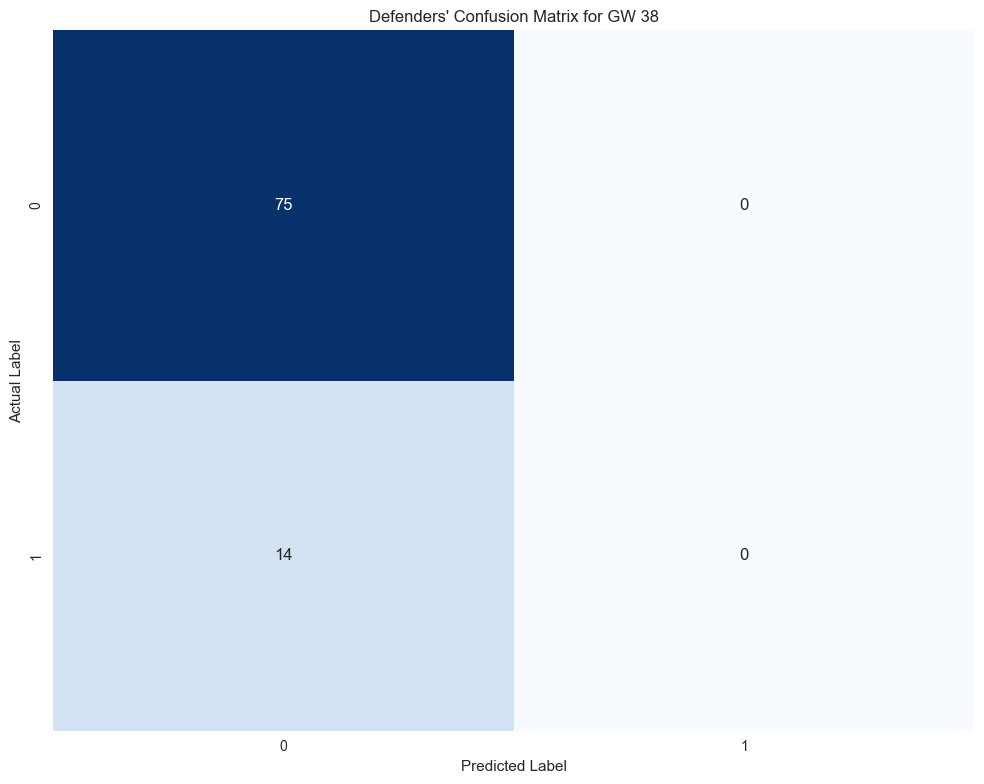

In [33]:
data_38_def_y = data_38_def[y_features]
y = data_38_def_y[['yellow_cards']].copy()
data_38_def_y.drop(columns=['position', 'yellow_cards'], inplace=True)

y_preds_38 = predict_model(def_y_model, data=data_38_def_y)
y_preds_38 = y_preds_38.rename(columns={'prediction_label': 'y_preds_trans'})

# Add y_preds_38 to data_38_def
data_38_def['y_preds'] = y_preds_38[['y_preds_trans']]


actual = y['yellow_cards'] # The actual classes
predicted = y_preds_38[['y_preds_trans']] # The predicted classes

cm = confusion_matrix(actual, predicted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Label the axes
plt.title('Defenders\' Confusion Matrix for GW 38')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()



## MID


In [34]:
# Load model
mid_y_model = load_model('../mid_y_model')

Transformation Pipeline and Model Successfully Loaded


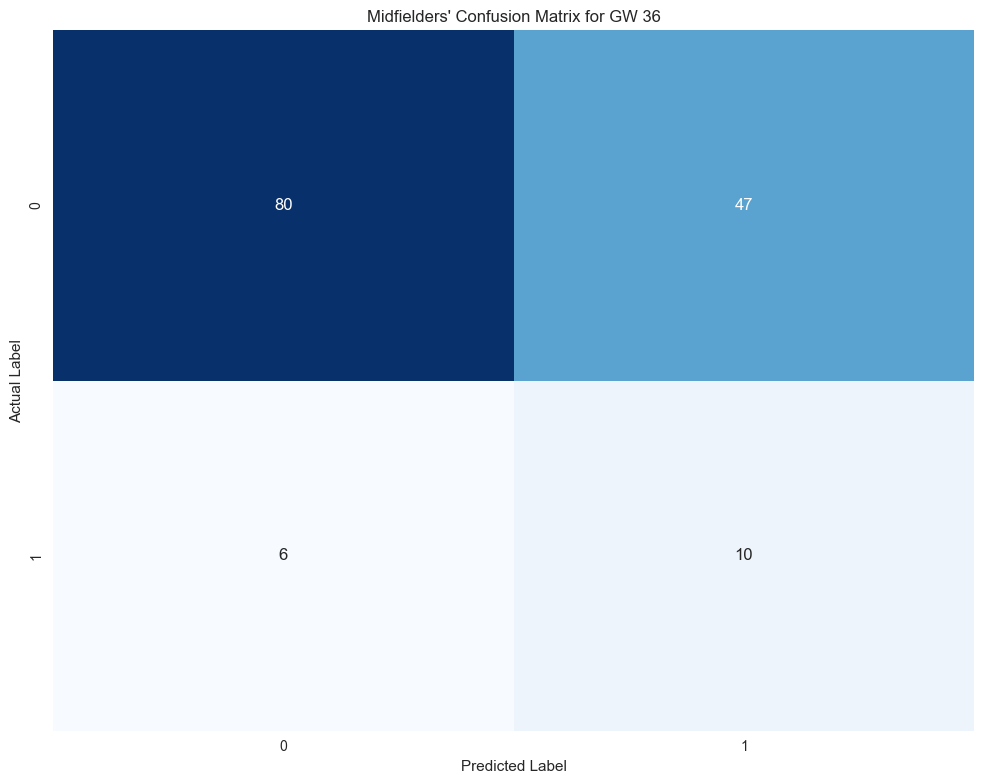

In [35]:
data_36_mid_y = data_36_mid[y_features]
y = data_36_mid_y[['yellow_cards']].copy()
data_36_mid_y.drop(columns=['position', 'yellow_cards'], inplace=True)

y_preds_36 = predict_model(mid_y_model, data=data_36_mid_y)
y_preds_36 = y_preds_36.rename(columns={'prediction_label': 'y_preds_trans'})

# Add y_preds_36 to data_36_mid
data_36_mid['y_preds'] = y_preds_36[['y_preds_trans']]


actual = y['yellow_cards'] # The actual classes
predicted = y_preds_36[['y_preds_trans']] # The predicted classes

cm = confusion_matrix(actual, predicted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Label the axes
plt.title('Midfielders\' Confusion Matrix for GW 36')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()



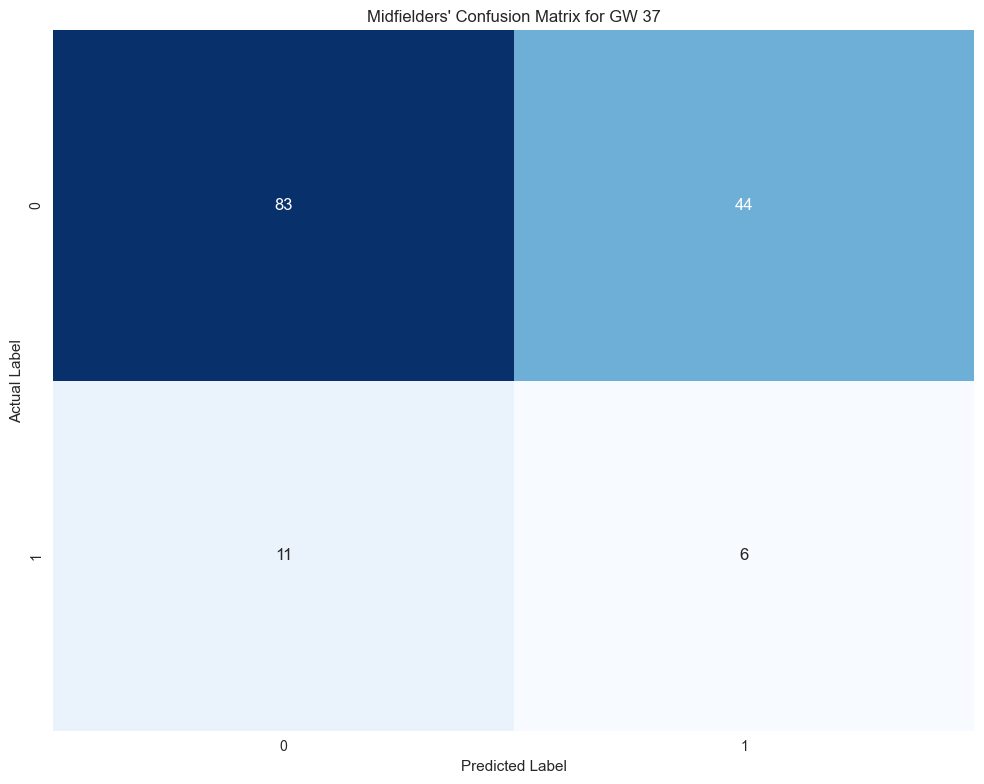

In [36]:
data_37_mid_y = data_37_mid[y_features]
y = data_37_mid_y[['yellow_cards']].copy()
data_37_mid_y.drop(columns=['position', 'yellow_cards'], inplace=True)

y_preds_37 = predict_model(mid_y_model, data=data_37_mid_y)
y_preds_37 = y_preds_37.rename(columns={'prediction_label': 'y_preds_trans'})

# Add y_preds_37 to data_37_mid
data_37_mid['y_preds'] = y_preds_37[['y_preds_trans']]


actual = y['yellow_cards'] # The actual classes
predicted = y_preds_37[['y_preds_trans']] # The predicted classes

cm = confusion_matrix(actual, predicted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Label the axes
plt.title('Midfielders\' Confusion Matrix for GW 37')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()



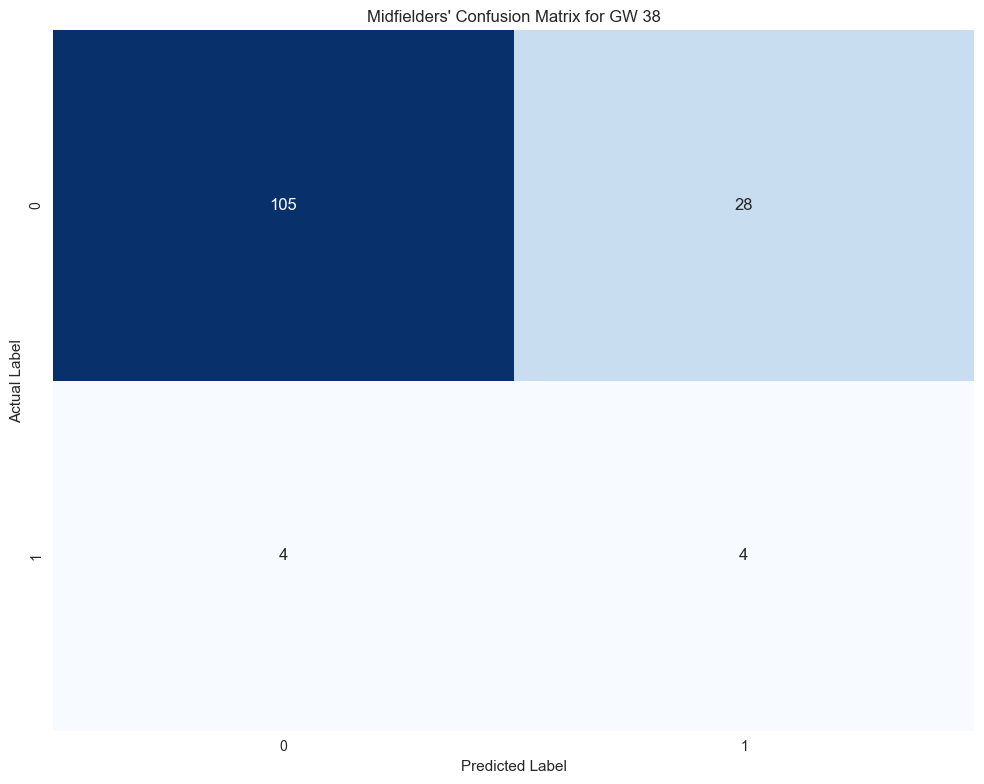

In [37]:
data_38_mid_y = data_38_mid[y_features]
y = data_38_mid_y[['yellow_cards']].copy()
data_38_mid_y.drop(columns=['position', 'yellow_cards'], inplace=True)

y_preds_38 = predict_model(mid_y_model, data=data_38_mid_y)
y_preds_38 = y_preds_38.rename(columns={'prediction_label': 'y_preds_trans'})

# Add y_preds_38 to data_38_mid
data_38_mid['y_preds'] = y_preds_38[['y_preds_trans']]


actual = y['yellow_cards'] # The actual classes
predicted = y_preds_38[['y_preds_trans']] # The predicted classes

cm = confusion_matrix(actual, predicted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Label the axes
plt.title('Midfielders\' Confusion Matrix for GW 38')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()



## FWD


In [38]:
# Load model
fwd_y_model = load_model('../fwd_y_model')

Transformation Pipeline and Model Successfully Loaded


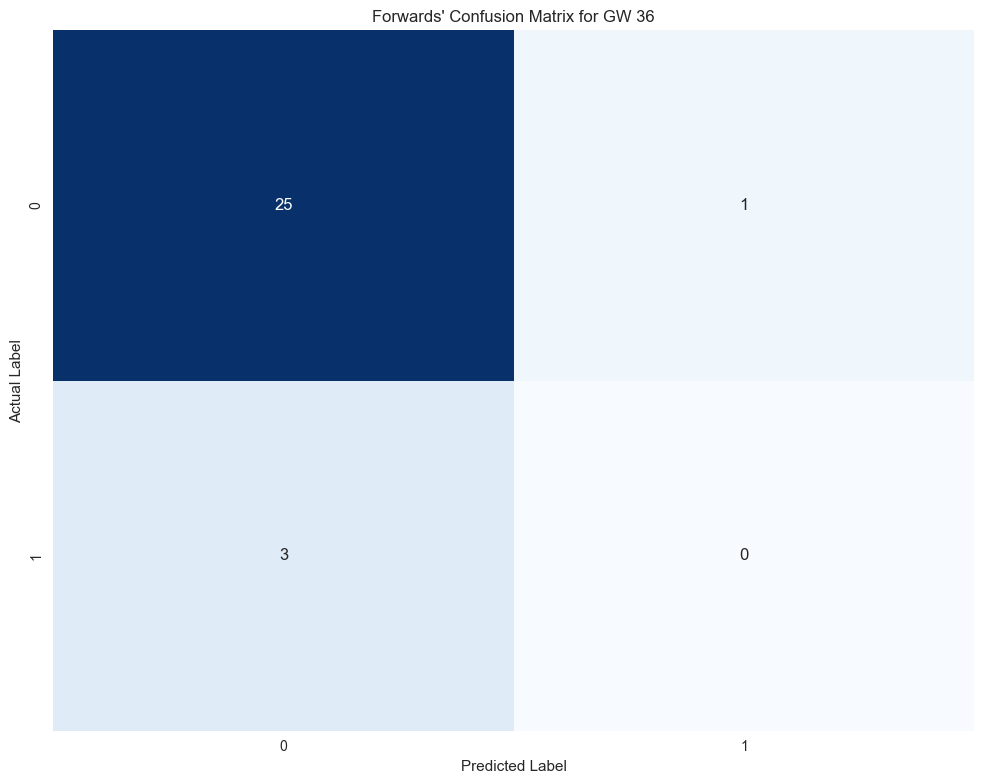

In [39]:
data_36_fwd_y = data_36_fwd[y_features]
y = data_36_fwd_y[['yellow_cards']].copy()
data_36_fwd_y.drop(columns=['position', 'yellow_cards'], inplace=True)

y_preds_36 = predict_model(fwd_y_model, data=data_36_fwd_y)
y_preds_36 = y_preds_36.rename(columns={'prediction_label': 'y_preds_trans'})

# Add y_preds_36 to data_36_fwd
data_36_fwd['y_preds'] = y_preds_36[['y_preds_trans']]


actual = y['yellow_cards'] # The actual classes
predicted = y_preds_36[['y_preds_trans']] # The predicted classes

cm = confusion_matrix(actual, predicted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Label the axes
plt.title('Forwards\' Confusion Matrix for GW 36')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()



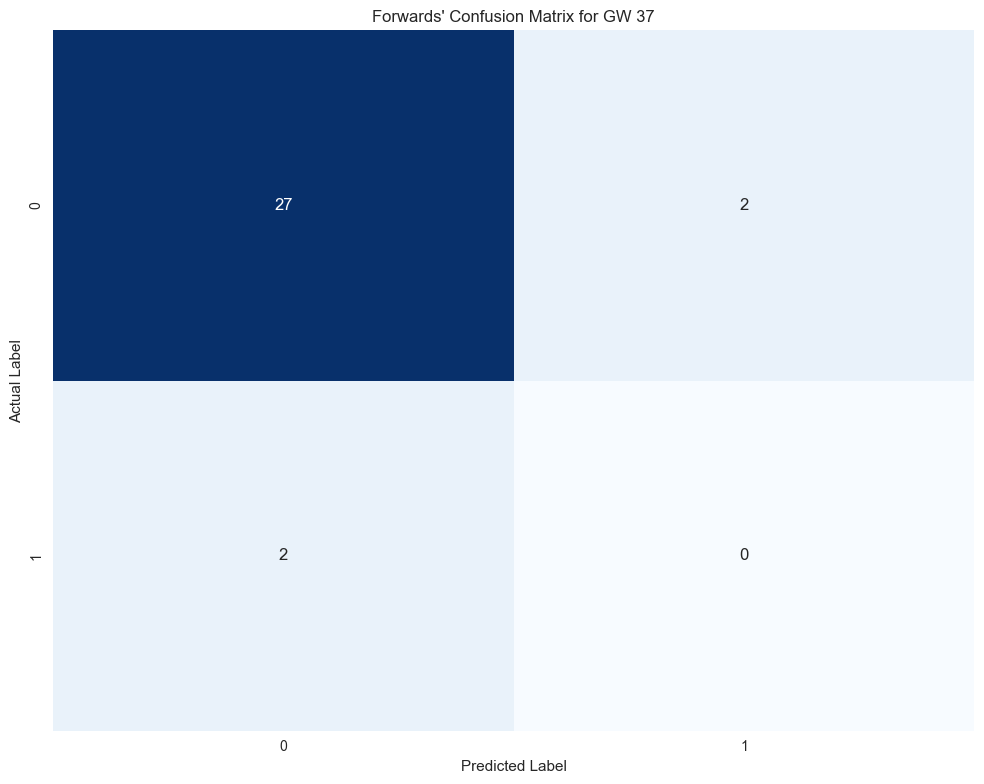

In [40]:
data_37_fwd_y = data_37_fwd[y_features]
y = data_37_fwd_y[['yellow_cards']].copy()
data_37_fwd_y.drop(columns=['position', 'yellow_cards'], inplace=True)

y_preds_37 = predict_model(fwd_y_model, data=data_37_fwd_y)
y_preds_37 = y_preds_37.rename(columns={'prediction_label': 'y_preds_trans'})

# Add y_preds_37 to data_37_fwd
data_37_fwd['y_preds'] = y_preds_37[['y_preds_trans']]


actual = y['yellow_cards'] # The actual classes
predicted = y_preds_37[['y_preds_trans']] # The predicted classes

cm = confusion_matrix(actual, predicted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Label the axes
plt.title('Forwards\' Confusion Matrix for GW 37')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()



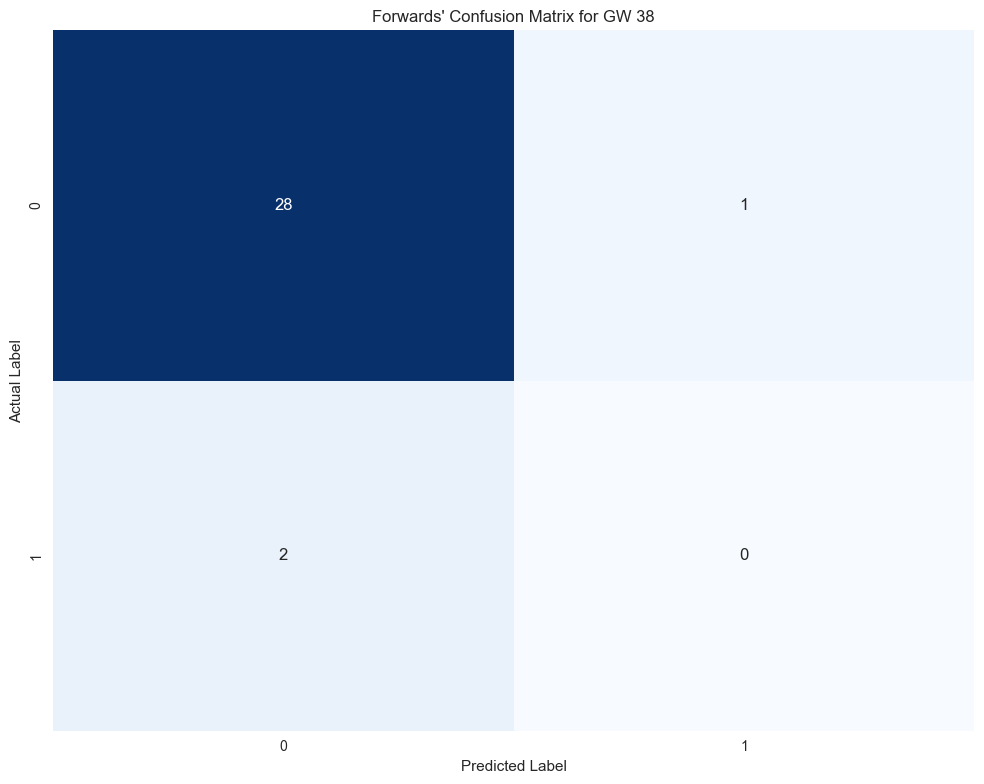

In [41]:
data_38_fwd_y = data_38_fwd[y_features]
y = data_38_fwd_y[['yellow_cards']].copy()
data_38_fwd_y.drop(columns=['position', 'yellow_cards'], inplace=True)

y_preds_38 = predict_model(fwd_y_model, data=data_38_fwd_y)
y_preds_38 = y_preds_38.rename(columns={'prediction_label': 'y_preds_trans'})

# Add y_preds_38 to data_38_fwd
data_38_fwd['y_preds'] = y_preds_38[['y_preds_trans']]


actual = y['yellow_cards'] # The actual classes
predicted = y_preds_38[['y_preds_trans']] # The predicted classes

cm = confusion_matrix(actual, predicted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Label the axes
plt.title('Forwards\' Confusion Matrix for GW 38')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()



# Combine Gw data predictions


In [59]:
# data_36 = pd.read_csv('./data_36_with_preds.csv', index_col=0)
data_36

,assists_x,bonus,bps,clean_sheets,creativity,element,expected_assists,expected_goal_involvements,expected_goals,expected_goals_conceded,...,pts_bps,whh,whd,wha,saves_preds,xgc_preds,xG_preds,xA_preds,y_preds,cs_preds
15,0,0,28,1,15.3,517,0.18,0.18,0.00,2.28,...,5.0,0.499,0.264,0.237,NaN,1.328116,3.984650e-10,0.046807,0,0.0
45,0,3,31,1,0.0,14,0.00,0.00,0.00,1.82,...,7.0,0.086,0.126,0.788,3.970791,1.898250,NaN,NaN,0,0.0
81,1,3,36,1,23.8,388,0.22,0.22,0.00,2.28,...,9.0,0.499,0.264,0.237,NaN,1.442402,1.065238e-02,0.120286,0,0.0
114,1,0,18,0,11.8,217,0.02,0.02,0.00,0.64,...,5.0,0.516,0.276,0.209,NaN,NaN,3.062384e-03,0.096075,1,0.0
184,0,0,-4,0,1.8,81,0.01,0.01,0.00,0.98,...,1.0,0.394,0.263,0.344,NaN,0.636863,3.547733e-04,0.000093,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10896,0,0,11,1,2.6,600,0.01,0.04,0.03,0.91,...,3.0,0.351,0.271,0.379,NaN,NaN,2.481391e-02,0.000309,1,0.0
10927,0,0,9,1,2.3,111,0.02,0.02,0.00,0.93,...,2.0,0.189,0.237,0.574,NaN,NaN,4.302760e-04,-0.000329,1,0.0
10967,0,0,7,1,13.4,110,0.08,0.63,0.55,0.76,...,1.0,0.189,0.237,0.574,NaN,NaN,4.096355e-01,0.074347,0,NaN
11019,0,0,3,0,0.1,97,0.00,0.00,0.00,0.17,...,1.0,0.189,0.237,0.574,NaN,NaN,4.703450e-03,0.004740,0,0.0


In [58]:
## GW 36
# Merge all the preds and sort by index
preds_36 = pd.concat([data_36_gk, data_36_def, data_36_mid, data_36_fwd]).sort_index()
cols_to_add = ['y_preds', 'cs_preds']

# Call the gw preds saved from the regressor
data_36 = pd.read_csv('./data_36_with_preds.csv', index_col=0)
# Now add the columns to the gw_data
data_36[cols_to_add] = preds_36[cols_to_add]

# Save the updated DataFrame
data_36.to_csv('./data_36_with_preds.csv')


## GW 37
# Merge all the preds and sort by index
preds_37 = pd.concat([data_37_gk, data_37_def, data_37_mid, data_37_fwd]).sort_index()
cols_to_add = ['y_preds', 'cs_preds']

# Call the gw preds saved from the regressor
data_37 = pd.read_csv('./data_37_with_preds.csv', index_col=0)
# Now add the columns to the gw_data
data_37[cols_to_add] = preds_37[cols_to_add]

# Save the updated DataFrame
data_37.to_csv('./data_37_with_preds.csv')

## GW 38
# Merge all the preds and sort by index
preds_38 = pd.concat([data_38_gk, data_38_def, data_38_mid, data_38_fwd]).sort_index()
cols_to_add = ['y_preds', 'cs_preds']

# Call the gw preds saved from the regressor
data_38 = pd.read_csv('./data_38_with_preds.csv', index_col=0)
# Now add the columns to the gw_data
data_38[cols_to_add] = preds_38[cols_to_add]

# Save the updated DataFrame
data_38.to_csv('./data_38_with_preds.csv')
